## Lab 8 

#### Canny Edge Detector

In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
from utils import print_image, apply_filter

In [2]:
head = cv2.imread("Images/Head.jpeg", cv2.IMREAD_GRAYSCALE)
house = cv2.imread("Images/House.jpeg", cv2.IMREAD_GRAYSCALE)

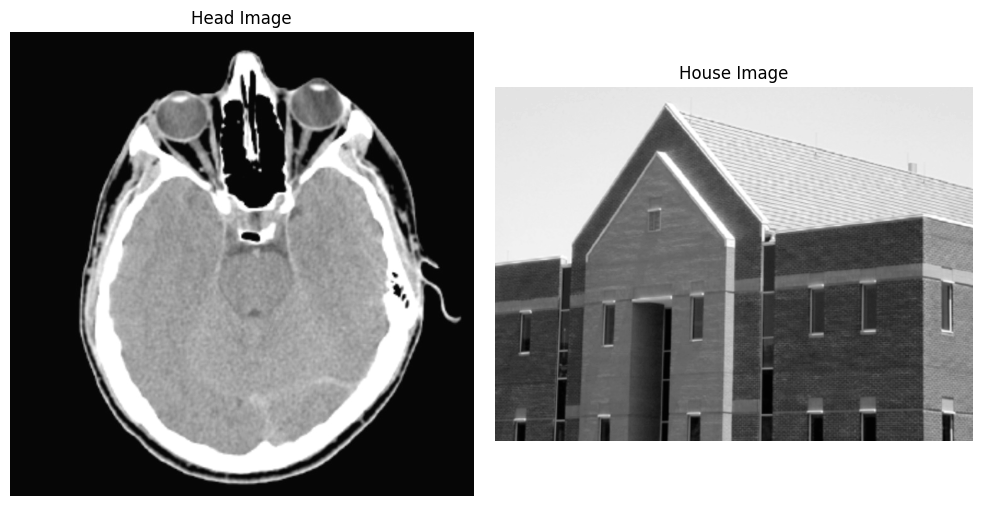

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(head, cmap='gray')
axes[0].set_title('Head Image')
axes[0].axis('off')

axes[1].imshow(house, cmap='gray')
axes[1].set_title('House Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [4]:
GX = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]])
GY = np.array([[1, 2, 1],
               [0, 0, 0],
               [-1, -2, -1]])

GAUSSIAN_FILTER = np.array([[1/16, 1/8, 1/16],
                            [1/8, 1/4, 1/8],
                            [1/16, 1/8, 1/16]])

In [5]:
def magnitude(gx, gy):
    return np.sqrt(gx**2 + gy**2)

In [6]:
import numpy as np

def quantize_directions(direction):
    angle = direction % 180
    
    quantized = np.zeros_like(angle)
    mask0 = (angle < 22.5) | (angle >= 157.5)
    quantized[mask0] = 0

    mask45 = (angle >= 22.5) & (angle < 67.5)
    quantized[mask45] = 45

    mask90 = (angle >= 67.5) & (angle < 112.5)
    quantized[mask90] = 90

    mask135 = (angle >= 112.5) & (angle < 157.5)
    quantized[mask135] = 135
    
    return quantized


In [7]:
def non_maximal_suppressing(
    magnitude,
    direction_quantized,
    low_threshold,
    high_threshold
):
    h, w = magnitude.shape
    suppressed = np.zeros_like(magnitude, dtype=np.float32)

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            angle = direction_quantized[i, j]
            current = magnitude[i, j]

            if angle == 0:
                n1, n2 = magnitude[i, j - 1], magnitude[i, j + 1]
            elif angle == 45:
                n1, n2 = magnitude[i - 1, j + 1], magnitude[i + 1, j - 1]
            elif angle == 90:
                n1, n2 = magnitude[i - 1, j], magnitude[i + 1, j]
            else:
                n1, n2 = magnitude[i - 1, j - 1], magnitude[i + 1, j + 1]

            if current >= n1 and current >= n2:
                suppressed[i, j] = current

    strong, weak = 255, 75
    mask = np.zeros_like(magnitude, dtype=np.uint8)
    high_thresh_mask = suppressed >= high_threshold
    low_thresh_mask = (suppressed >= low_threshold) & (suppressed < high_threshold)
    mask[high_thresh_mask] = strong
    mask[low_thresh_mask] = weak

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            if mask[i, j] == weak:
                if np.any(mask[i - 1:i + 2, j - 1:j + 2] == strong):
                    mask[i, j] = strong
                else:
                    mask[i, j] = 0

    return mask

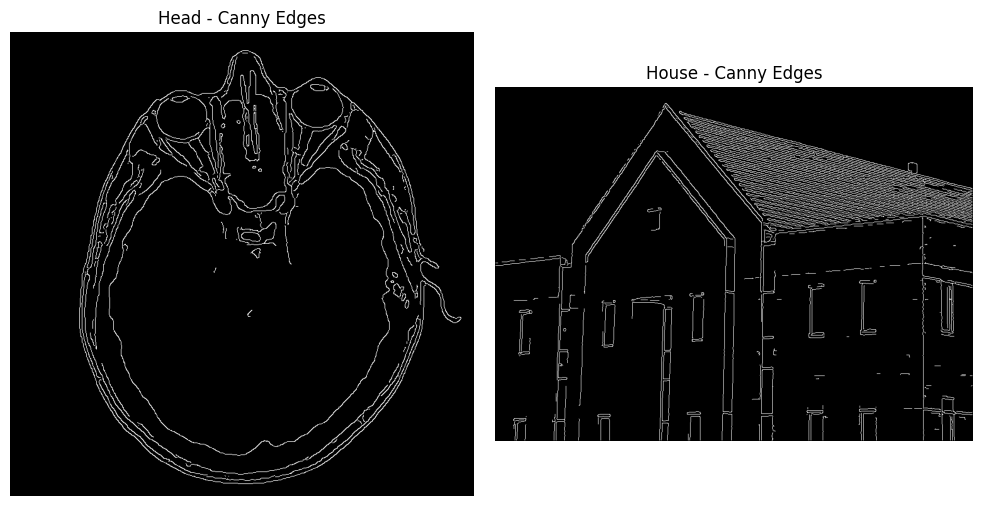

In [8]:
def canny_edge_detection(image, low_threshold, high_threshold):
    if image.ndim == 2:
        image_3d = image[:, :, np.newaxis].astype(np.float32)
    else:
        image_3d = image.astype(np.float32)

    smoothed = apply_filter(image_3d, GAUSSIAN_FILTER).squeeze()
    gx_img = apply_filter(smoothed[:, :, np.newaxis], GX).squeeze()
    gy_img = apply_filter(smoothed[:, :, np.newaxis], GY).squeeze()
    magnitude_img = magnitude(gx_img, gy_img)
    direction = np.arctan2(gy_img, gx_img) * (180.0 / np.pi)
    direction_quantized = quantize_directions(direction)

    edges = non_maximal_suppressing(
        magnitude_img, direction_quantized, low_threshold, high_threshold
    )
    return edges


head_edges = canny_edge_detection(head, low_threshold=30, high_threshold=70)
house_edges = canny_edge_detection(house, low_threshold=30, high_threshold=70)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(head_edges, cmap='gray')
axes[0].set_title('Head - Canny Edges')
axes[0].axis('off')

axes[1].imshow(house_edges, cmap='gray')
axes[1].set_title('House - Canny Edges')
axes[1].axis('off')

plt.tight_layout()
plt.show()